# 3D Plotting with Matplotlib
## Milestone 4: Interactive Visualization

### Objective
In this milestone, you will create an interactive surface plot to visualize the hourly mean number of bikes rented along with the mean temperature at that hour. You will use a customized colormap to distinguish hotter hours.

### Importance of the Project
Interactive plots enable you to inspect the relations between features of your dataset from different points of view. The plot created in this milestone will enable you to visualize the patterns in hourly renting of bikes with variations in the temperature.

### 1. Import libraries and get data ready

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import matplotlib as mpl
print(mpl.pyplot.get_backend())

module://matplotlib_inline.backend_inline


In [3]:
plt.rcParams["backend"]

'module://matplotlib_inline.backend_inline'

In [4]:
from mpl_toolkits import mplot3d

In [5]:
%matplotlib --list

Available matplotlib backends: ['agg', 'auto', 'cairo', 'gtk3', 'gtk3agg', 'gtk3cairo', 'gtk4', 'gtk4agg', 'gtk4cairo', 'inline', 'ipympl', 'macosx', 'nbagg', 'notebook', 'osx', 'pdf', 'pgf', 'ps', 'qt', 'qt5', 'qt5agg', 'qt5cairo', 'qt6', 'qtagg', 'qtcairo', 'svg', 'template', 'tk', 'tkagg', 'tkcairo', 'webagg', 'widget', 'wx', 'wx', 'wxagg', 'wxcairo']


#### Read the SeoulBikesData.csv file into a pandas DataFrame

In [6]:
data_loc = "./data/"
img_loc = "./img/"

In [7]:
bikes = pd.read_csv(data_loc + "SeoulBikeData.csv",  
                    encoding = 'unicode_escape',   
                    parse_dates=['Date'],
                    date_format = "%d/%m/%Y"  
                  )

In [8]:
bikes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       8760 non-null   datetime64[ns]
 1   Rented Bike Count          8760 non-null   int64         
 2   Hour                       8760 non-null   int64         
 3   Temperature(°C)            8760 non-null   float64       
 4   Humidity(%)                8760 non-null   int64         
 5   Wind speed (m/s)           8760 non-null   float64       
 6   Visibility (10m)           8760 non-null   int64         
 7   Dew point temperature(°C)  8760 non-null   float64       
 8   Solar Radiation (MJ/m2)    8760 non-null   float64       
 9   Rainfall(mm)               8760 non-null   float64       
 10  Snowfall (cm)              8760 non-null   float64       
 11  Seasons                    8760 non-null   object        
 12  Holida

In [9]:
bikes.sample(5)

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
2720,2018-03-24,424,8,4.5,49,0.4,580,-5.3,0.19,0.0,0.0,Spring,No Holiday,Yes
833,2018-01-04,397,17,-2.1,37,1.4,1591,-14.8,0.09,0.0,0.0,Winter,No Holiday,Yes
5358,2018-07-12,593,6,25.6,93,1.1,852,24.3,0.01,0.0,0.0,Summer,No Holiday,Yes
5486,2018-07-17,786,14,31.8,49,3.5,1429,19.7,2.93,0.0,0.0,Summer,No Holiday,Yes
1502,2018-02-01,256,14,0.8,23,3.2,2000,-18.0,1.29,0.0,0.5,Winter,No Holiday,Yes


In [10]:
bikes.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day'],
      dtype='object')

#### Group your DataFrame by hour and apply mean() to compute the mean of all numerical columns

#### Round the values to two decimal places

In [11]:
bikes_by_hour = bikes[['Hour', 'Rented Bike Count',  'Temperature(°C)']].groupby(["Hour"]).mean().round(2)
bikes_by_hour

,Rented Bike Count,Temperature(°C)
Hour,,
0,541.46,11.29
1,426.18,10.92
2,301.63,10.59
3,203.33,10.29
4,132.59,10.03
5,139.08,9.77
6,287.56,9.56
7,606.01,9.58
8,1015.70,10.18


In [12]:
bikes_by_hour.reset_index(inplace = True)
bikes_by_hour

,Hour,Rented Bike Count,Temperature(°C)
0,0,541.46,11.29
1,1,426.18,10.92
2,2,301.63,10.59
3,3,203.33,10.29
4,4,132.59,10.03
5,5,139.08,9.77
6,6,287.56,9.56
7,7,606.01,9.58
8,8,1015.70,10.18
9,9,645.98,11.38


In [13]:
bikes_by_hour.sort_values("Temperature(°C)")

,Hour,Rented Bike Count,Temperature(°C)
6,6,287.56,9.56
7,7,606.01,9.58
5,5,139.08,9.77
4,4,132.59,10.03
8,8,1015.70,10.18
3,3,203.33,10.29
2,2,301.63,10.59
1,1,426.18,10.92
0,0,541.46,11.29
9,9,645.98,11.38


### 2. Set the backend of your Jupyter notebook to an interactive backend

In [14]:
print(mpl.pyplot.get_backend())

module://matplotlib_inline.backend_inline


In [15]:
%matplotlib qt

In [16]:
print(mpl.pyplot.get_backend())

qtagg


### 3. Create a custom colormap to use with your plot

#### Import ListedColormap from the matplotlib.colors module

In [17]:
from matplotlib.colors import ListedColormap

In [18]:
import seaborn as sns

In [19]:
sns.color_palette("Set2")

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
 (0.6509803921568628, 0.8470588235294118, 0.32941176470588235),
 (1.0, 0.8509803921568627, 0.1843137254901961),
 (0.8980392156862745, 0.7686274509803922, 0.5803921568627451),
 (0.7019607843137254, 0.7019607843137254, 0.7019607843137254)]

In [20]:
print(sns.color_palette("Set2").as_hex())

['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854', '#ffd92f', '#e5c494', '#b3b3b3']


In [21]:
sns.color_palette("viridis",8)

[(0.281412, 0.155834, 0.469201),
 (0.244972, 0.287675, 0.53726),
 (0.190631, 0.407061, 0.556089),
 (0.147607, 0.511733, 0.557049),
 (0.119699, 0.61849, 0.536347),
 (0.20803, 0.718701, 0.472873),
 (0.430983, 0.808473, 0.346476),
 (0.709898, 0.868751, 0.169257)]

In [22]:
print(sns.color_palette("viridis",8).as_hex())

['#482878', '#3e4989', '#31688e', '#26828e', '#1f9e89', '#35b779', '#6ece58', '#b5de2b']


#### Create a new colormap object by passing a list of colors to ListedColormap()

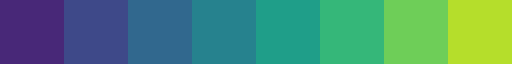

In [23]:
my_colors = ListedColormap(['#482878', '#3e4989', '#31688e', '#26828e', 
                            '#1f9e89', '#35b779', '#6ece58', '#b5de2b'])
my_colors

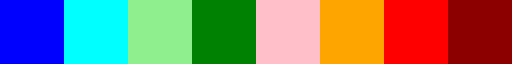

In [24]:
favorite_colors = ListedColormap(["blue", "cyan", "lightgreen", "green", 
                            "pink", "orange", "red", "darkred"])
favorite_colors

### 4. Extract the columns Hour, Rented Bike Count, and Temperature from the grouped data
- Hours will be plotted on the x-axis.
- Rented Bike Count will be plotted on the y-axis.
- Temperature will be plotted on the z-axis.

### 5. Initialize a figure object and add a subplot to it

In [25]:
fig, ax = plt.subplots(
        figsize = (10,10), 
        subplot_kw=dict(projection='3d'))
plt.show()

### 6. Plot the trisurface plot.
- Use the columns extracted in Step 4
- Use the colormap created in Step 3

In [26]:
fig, ax = plt.subplots(
        figsize = (10,10), 
        subplot_kw=dict(projection='3d'))
ax.plot_trisurf(bikes_by_hour['Hour'], 
                bikes_by_hour['Temperature(°C)'], 
                bikes_by_hour['Rented Bike Count'], 
                cmap = my_colors, 
                linewidth=0.2)
plt.show()

### 7. Add a color bar to your plot.
- This should reflect values of temperature as colors
- You can add a label to the color bar

In [27]:
fig, ax = plt.subplots(
        figsize = (10,10), 
        subplot_kw=dict(projection='3d'))
tri_plot = ax.plot_trisurf(bikes_by_hour['Hour'], 
                bikes_by_hour['Temperature(°C)'], 
                bikes_by_hour['Rented Bike Count'],            
                cmap = my_colors, 
                linewidth=0.2)
fig.colorbar(tri_plot, ax = ax, shrink = 0.6)
plt.show()

### 8. Set the axes ticks for your plot

### 9. Set the axes labels and overall title for your plot.

### 10. Save your plot as a png file with a resolution of 300 dpi

In [28]:
fig, ax = plt.subplots(
        figsize = (10,10), 
        subplot_kw=dict(projection='3d'))
tri_plot = ax.plot_trisurf(bikes_by_hour['Hour'], 
                bikes_by_hour['Temperature(°C)'], 
                bikes_by_hour['Rented Bike Count'],                 
                cmap = my_colors, 
                linewidth=0.2)
ax.set(xticks = range(0,24,2), xticklabels = range(0,24,2), 
       xlabel = 'Hour',
       ylabel = 'Temperature(°C)',
       zlabel = 'Avg. Rented Bike Count'
)
ax.set_title(label = "Mean of Rented Bikes per Hour and Temperature", 
             fontsize = 11)
fig.colorbar(tri_plot, ax = ax, shrink = 0.6)
fig.savefig(img_loc+'P2_M4.png', dpi = 300)
plt.show()

### Trisurface Plot


#### 1. **Plot Overview**

This is a **3D triangular surface plot** that shows how bike rentals vary by hour of the day and temperature.

* **X-axis (Hour):** ranges from 0 to 23, representing the hours of the day.
* **Y-axis (Temperature in °C):** captures average temperatures.
* **Z-axis (Avg. Rented Bike Count):** shows the mean number of bikes rented.
* **Color gradient (cmap):** indicates rental levels, with cooler/darker shades for lower counts and warmer/brighter shades for higher counts.

This visualization helps answer:

* At what times of day and at what temperatures do rentals peak?
* How sensitive is bike rental behavior to both time and temperature?

---

#### 2. **Code Breakdown**

```python
fig, ax = plt.subplots(
        figsize = (10,10), 
        subplot_kw=dict(projection='3d'))
```

* Creates a 10x10 inch figure.
* `subplot_kw=dict(projection='3d')` ensures a 3D axes object.

```python
tri_plot = ax.plot_trisurf(bikes_by_hour['Hour'], 
                bikes_by_hour['Temperature(°C)'], 
                bikes_by_hour['Rented Bike Count'],                 
                cmap = my_colors, 
                linewidth=0.2)
```

* `ax.plot_trisurf(...)` → generates a 3D triangular surface.
* Takes three variables: Hour (x), Temperature (y), Rentals (z).
* `cmap=my_colors` applies a colormap for visual encoding.
* `linewidth=0.2` gives a subtle outline to the surface triangles.

```python
ax.set(xticks = range(0,24,2), xticklabels = range(0,24,2), 
       xlabel = 'Hour',
       ylabel = 'Temperature(°C)',
       zlabel = 'Avg. Rented Bike Count'
)
```

* Configures x-axis ticks (every 2 hours).
* Labels all three axes for clarity.

```python
ax.set_title(label = "Mean of Rented Bikes per Hour and Temperature", 
             fontsize = 11)
```

* Adds a descriptive title.

```python
fig.colorbar(tri_plot, ax = ax, shrink = 0.6)
```

* Adds a colorbar showing the mapping from colors → rental counts.
* `shrink=0.6` makes it proportionally smaller to fit the plot layout.

```python
fig.savefig(img_loc+'P2_M4.png', dpi = 300)
plt.show()
```

* Saves the figure as a PNG at 300 dpi (high resolution).
* Displays it in the notebook/output.

---

#### 3. **Questions for Reflecting on Visual Elements**

* What do you notice about the surface shape — are there steep peaks or broad flat areas?
* How does the color gradient reinforce the z-axis values (rental counts)?
* Use the 3D interface to rotate the view to appreciate the peaks and valleys. 

---

#### 4. **Data Interpretation: Explore these questions to deepen your understanding**

* At what hours and temperatures do rentals peak? (e.g., mid-evenings at mild temperatures).
* Do rentals fall sharply outside of certain ranges? (e.g., very late night or lower temperatures).
* Does the 3D perspective help you see interactions between hour and temperature, or would another plot (like a heatmap) clarify further?

---

#### 5. **Learning Points**

* **Key concept:** `plot_trisurf` is excellent for 3D visualizations when data points are not on a uniform grid.
* **Use case:** exploring interactions among three variables (two predictors, one outcome).
* **Common mistakes:**

  * Forgetting to set `projection='3d'`.
  * Using too few points → jagged, uninformative surfaces.


## Other Plots

### Trisurface plot of sin(-x*y)

In [29]:
n_radii = 8
n_angles = 36

# Make radii and angles spaces (radius r=0 omitted to eliminate duplication).
radii = np.linspace(0.125, 1.0, n_radii)
angles = np.linspace(0, 2*np.pi, n_angles, endpoint=False)[..., np.newaxis]

# Convert polar (radii, angles) coords to cartesian (x, y) coords.
# (0, 0) is manually added at this stage,  so there will be no duplicate
# points in the (x, y) plane.
x = np.append(0, (radii*np.cos(angles)).flatten())
y = np.append(0, (radii*np.sin(angles)).flatten())

# Compute z to make the pringle surface.
z = np.sin(-x*y)

fig, ax = plt.subplots(
        figsize = (10,10), 
        subplot_kw=dict(projection='3d'))

tri_plot = ax.plot_trisurf(x, y, z, linewidth=0.2, antialiased=True, cmap = my_colors)
ax.set(xlabel = 'x',
       ylabel = 'y',
       zlabel = 'sin(-x*y)')
ax.set_title(label = "Trisurface Plot of Sin (-x * y)", 
             fontsize = 11)

fig.colorbar(tri_plot, ax = ax, shrink = 0.6)

plt.show()

### 3D Scatterplot of sin(-x*y)

In [30]:
fig, ax = plt.subplots(
        figsize = (10,10), 
        subplot_kw=dict(projection='3d'))
tri_plot = ax.scatter3D(x, 
                y, 
                z)
ax.set(xlabel = 'x',
       ylabel = 'y',
       zlabel = 'sin(-x*y)')
ax.set_title(label = "3D Scatterplot of Sin (-x * y)", 
             fontsize = 11)
plt.show()

In [31]:
from matplotlib.tri import Triangulation

# Sample data points
x = np.random.rand(40)
y = np.random.rand(40)
z = np.sin(2 * np.pi * (x**2 + y**2))

# Compute the triangulation
triangles = Triangulation(x, y)

# Create 3D plot
fig, ax = plt.subplots(
        figsize = (10,10), 
        subplot_kw=dict(projection='3d'))

# Plot the trisurface
ax.plot_trisurf(x, y, z, triangles=triangles.triangles, cmap="viridis")

plt.show()

### Scatterplot with x: Hour, y: Temperature, z: Bike Count

In [32]:
fig, ax = plt.subplots(
        figsize = (10,10), 
        subplot_kw=dict(projection='3d'))
scatter_plot_3D = ax.scatter3D(bikes_by_hour['Hour'], 
                bikes_by_hour['Temperature(°C)'], 
                bikes_by_hour['Rented Bike Count'], 
                c = bikes_by_hour['Rented Bike Count'],
                linewidth=0.2,
                alpha = 1)
ax.set(xticks = range(0,24,2), xticklabels = range(0,24,2), 
       xlabel = 'Hour',
       ylabel = 'Temperature(°C)',
       zlabel = 'Avg. Rented Bike Count',
)
ax.set_title(label = "Mean of Rented Bikes per Hour and Temperature", 
             fontsize = 11)
fig.colorbar(scatter_plot_3D, ax = ax, shrink = 0.6)

plt.show()